<a href="https://colab.research.google.com/github/rvs0514/quant1/blob/main/quant_risk_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Quant Trading: Risk & Performance Analytics





## 🔧 Setup — Install & Import Libraries

In [ ]:
# Install yfinance (not pre-installed in Colab)
!pip install yfinance --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import yfinance as yf
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Chart styling
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


---
## 📥 Module 1 — Download Market Data

We will download **SPY** (S&P 500 ETF) as our core strategy, and **^VIX** (Volatility Index) to analyse market regimes.  
We simulate a simple **momentum strategy**: go long when 20-day return is positive, else go to cash.

In [ ]:
# ── Download price data ──────────────────────────────────────────────────────
START = '2015-01-01'
END   = '2024-12-31'

print('Downloading SPY and VIX data...')
spy = yf.download('SPY', start=START, end=END, auto_adjust=True)['Close'].squeeze()
vix = yf.download('^VIX', start=START, end=END, auto_adjust=True)['Close'].squeeze()

# ── Daily returns ────────────────────────────────────────────────────────────
spy_returns = spy.pct_change().dropna()
spy_returns.name = 'SPY Returns'

# ── Simple Momentum Strategy ─────────────────────────────────────────────────
# Signal: if 20-day trailing return > 0, go long (signal = +1), else flat (signal = 0)
momentum_signal = (spy.pct_change(20).shift(1) > 0).astype(int)
strategy_returns = momentum_signal * spy_returns
strategy_returns.name = 'Strategy Returns'

# Align all data
df = pd.DataFrame({
    'spy_returns':      spy_returns,
    'strategy_returns': strategy_returns,
    'signal':           momentum_signal,
    'vix':              vix
}).dropna()

print(f'✅ Data loaded: {df.index[0].date()} → {df.index[-1].date()}  ({len(df)} trading days)')
df.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

✅ Data loaded: 2015-01-05 → 2024-12-30  (2514 trading days)


,spy_returns,strategy_returns,signal,vix
Date,,,,
2015-01-05,-0.018060,-0.0,0,19.920000
2015-01-06,-0.009419,-0.0,0,21.120001
2015-01-07,0.012461,0.0,0,19.309999
2015-01-08,0.017745,0.0,0,17.010000
2015-01-09,-0.008014,-0.0,0,17.549999


In [ ]:
display(df.head())

,spy_returns,strategy_returns,signal,vix
Date,,,,
2015-01-05,-0.018060,-0.0,0,19.920000
2015-01-06,-0.009419,-0.0,0,21.120001
2015-01-07,0.012461,0.0,0,19.309999
2015-01-08,0.017745,0.0,0,17.010000
2015-01-09,-0.008014,-0.0,0,17.549999


---
## 📐 Module 2 — Core Performance Metrics

### 2.1 — Sharpe Ratio

The **Sharpe Ratio** measures return per unit of risk.  
A Sharpe > 1.0 is generally considered good; > 2.0 is excellent.

$$\text{Sharpe} = \frac{\text{Mean Daily Return}}{\text{Std Daily Return}} \times \sqrt{252}$$

In [ ]:
def sharpe_ratio(returns, risk_free=0.0, periods=252):
    """
    Annualised Sharpe Ratio.

    Parameters:
        returns    : pd.Series of daily returns
        risk_free  : daily risk-free rate (default 0)
        periods    : trading days per year (252)
    """
    excess = returns - risk_free
    if excess.std() == 0:
        return 0
    return (excess.mean() / excess.std()) * np.sqrt(periods)


sr_spy      = sharpe_ratio(df['spy_returns'])
sr_strategy = sharpe_ratio(df['strategy_returns'])

print('=' * 40)
print(f'  SPY Buy & Hold  Sharpe: {sr_spy:.2f}')
print(f'  Momentum Strategy Sharpe: {sr_strategy:.2f}')
print('=' * 40)
print()
print('📌 Interpretation:')
print(f'  Sharpe > 1.0  → Good | > 2.0 → Excellent | < 0 → Strategy losing money')

  SPY Buy & Hold  Sharpe: 0.79
  Momentum Strategy Sharpe: 0.93

📌 Interpretation:
  Sharpe > 1.0  → Good | > 2.0 → Excellent | < 0 → Strategy losing money


### 2.2 — Maximum Drawdown

**Max Drawdown** is the largest peak-to-trough decline in cumulative returns.  
It tells you the worst loss an investor would have experienced.

$$\text{Max Drawdown} = \frac{\text{Trough Value} - \text{Peak Value}}{\text{Peak Value}}$$

  SPY Buy & Hold   Max Drawdown: -33.7%
  Momentum Strategy Max Drawdown: -13.3%


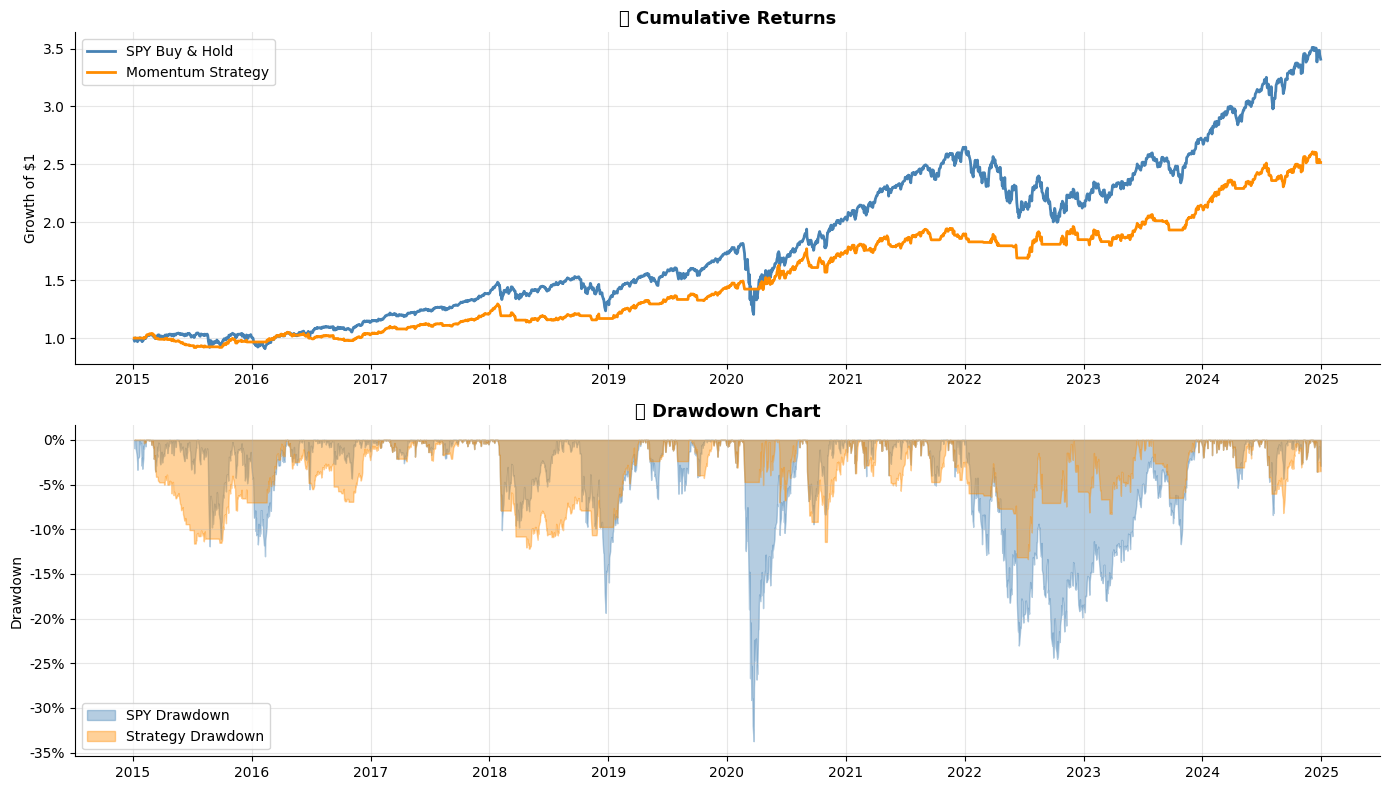

In [ ]:
def max_drawdown(returns):
    """
    Compute max drawdown and return the drawdown series for plotting.
    Returns: (max_dd float, drawdown_series pd.Series)
    """
    cum_returns  = (1 + returns).cumprod()
    rolling_max  = cum_returns.cummax()
    drawdown     = (cum_returns - rolling_max) / rolling_max
    return drawdown.min(), drawdown


mdd_spy,      dd_spy      = max_drawdown(df['spy_returns'])
mdd_strategy, dd_strategy = max_drawdown(df['strategy_returns'])

print(f'  SPY Buy & Hold   Max Drawdown: {mdd_spy:.1%}')
print(f'  Momentum Strategy Max Drawdown: {mdd_strategy:.1%}')

# ── Plot cumulative returns and drawdowns ────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Cumulative returns
cum_spy      = (1 + df['spy_returns']).cumprod()
cum_strategy = (1 + df['strategy_returns']).cumprod()

axes[0].plot(cum_spy,      label='SPY Buy & Hold', color='steelblue', lw=2)
axes[0].plot(cum_strategy, label='Momentum Strategy', color='darkorange', lw=2)
axes[0].set_title('📈 Cumulative Returns', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Growth of $1')
axes[0].legend()

# Drawdowns
axes[1].fill_between(dd_spy.index,      dd_spy,      0, alpha=0.4, color='steelblue',   label='SPY Drawdown')
axes[1].fill_between(dd_strategy.index, dd_strategy, 0, alpha=0.4, color='darkorange',  label='Strategy Drawdown')
axes[1].set_title('📉 Drawdown Chart', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Drawdown')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[1].legend()

plt.tight_layout()
plt.show()

### 2.3 — Annualised Volatility

**Volatility** = annualised standard deviation of daily returns.  
It measures total risk — the higher, the more the strategy swings around.

$$\text{Volatility} = \sigma_{daily} \times \sqrt{252}$$

  SPY Annualised Vol:       17.6%
  Strategy Annualised Vol:  10.5%


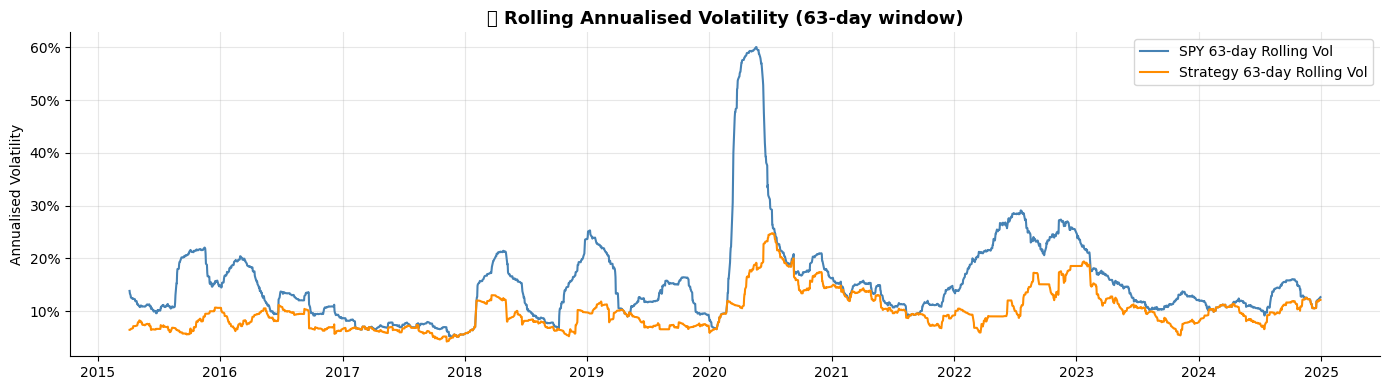

In [ ]:
def annualised_volatility(returns, periods=252):
    return returns.std() * np.sqrt(periods)


vol_spy      = annualised_volatility(df['spy_returns'])
vol_strategy = annualised_volatility(df['strategy_returns'])

# Rolling 63-day volatility (≈ 1 quarter)
roll_vol_spy      = df['spy_returns'].rolling(63).std() * np.sqrt(252)
roll_vol_strategy = df['strategy_returns'].rolling(63).std() * np.sqrt(252)

print(f'  SPY Annualised Vol:       {vol_spy:.1%}')
print(f'  Strategy Annualised Vol:  {vol_strategy:.1%}')

plt.figure(figsize=(14, 4))
plt.plot(roll_vol_spy,      label='SPY 63-day Rolling Vol',      color='steelblue', lw=1.5)
plt.plot(roll_vol_strategy, label='Strategy 63-day Rolling Vol', color='darkorange', lw=1.5)
plt.title('📊 Rolling Annualised Volatility (63-day window)', fontsize=13, fontweight='bold')
plt.ylabel('Annualised Volatility')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.legend()
plt.tight_layout()
plt.show()

### 2.4 — Turnover

**Turnover** measures how much a strategy trades — how often positions change.  
High turnover = high transaction costs in the real world.

$$\text{Daily Turnover} = |\text{Signal}_t - \text{Signal}_{t-1}|$$

  Annualised Turnover: 21.1x per year
  Number of trades:    210 total position changes

📌 Interpretation:
  1x = full portfolio turns over once a year (relatively low cost)
  10x+ = very high frequency, costs can eat all your alpha


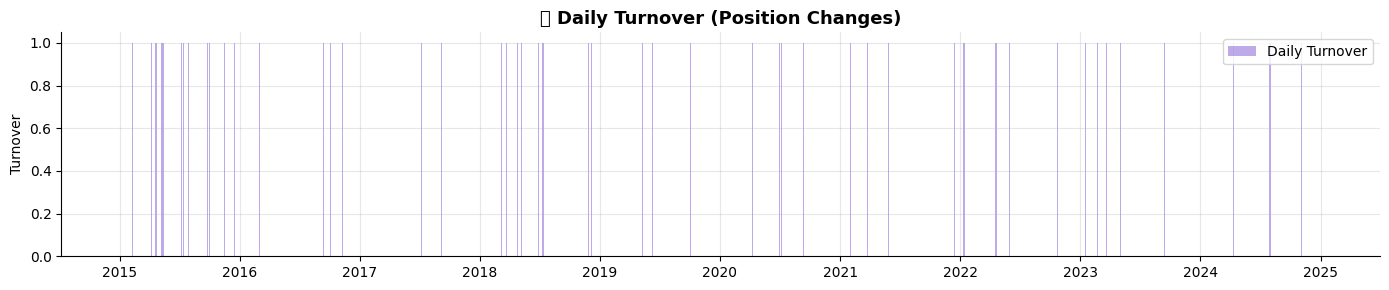

In [ ]:
def compute_turnover(signal):
    """
    Daily turnover = absolute change in position.
    Annualised turnover = mean daily turnover * 252
    """
    daily_to      = signal.diff().abs()
    annual_to     = daily_to.mean() * 252
    return daily_to, annual_to


daily_to, annual_to = compute_turnover(df['signal'])

print(f'  Annualised Turnover: {annual_to:.1f}x per year')
print(f'  Number of trades:    {int(daily_to.sum())} total position changes')
print()
print('📌 Interpretation:')
print('  1x = full portfolio turns over once a year (relatively low cost)')
print('  10x+ = very high frequency, costs can eat all your alpha')

# Show turnover over time
plt.figure(figsize=(14, 3))
plt.bar(daily_to.index, daily_to, color='mediumpurple', alpha=0.6, label='Daily Turnover')
plt.title('🔄 Daily Turnover (Position Changes)', fontsize=13, fontweight='bold')
plt.ylabel('Turnover')
plt.legend()
plt.tight_layout()
plt.show()

### 2.5 — Full Performance Summary Table

In [ ]:
def calmar_ratio(returns, periods=252):
    ann_return = returns.mean() * periods
    mdd, _     = max_drawdown(returns)
    return ann_return / abs(mdd) if mdd != 0 else np.nan

def sortino_ratio(returns, periods=252, mar=0):
    downside = returns[returns < mar]
    if downside.std() == 0:
        return np.nan
    return (returns.mean() * periods) / (downside.std() * np.sqrt(periods))


summary = pd.DataFrame({
    'SPY Buy & Hold': {
        'Ann. Return':     f"{df['spy_returns'].mean()*252:.1%}",
        'Ann. Volatility': f"{annualised_volatility(df['spy_returns']):.1%}",
        'Sharpe Ratio':    f"{sharpe_ratio(df['spy_returns']):.2f}",
        'Sortino Ratio':   f"{sortino_ratio(df['spy_returns']):.2f}",
        'Max Drawdown':    f"{max_drawdown(df['spy_returns'])[0]:.1%}",
        'Calmar Ratio':    f"{calmar_ratio(df['spy_returns']):.2f}",
        'Annual Turnover': 'N/A'
    },
    'Momentum Strategy': {
        'Ann. Return':     f"{df['strategy_returns'].mean()*252:.1%}",
        'Ann. Volatility': f"{annualised_volatility(df['strategy_returns']):.1%}",
        'Sharpe Ratio':    f"{sharpe_ratio(df['strategy_returns']):.2f}",
        'Sortino Ratio':   f"{sortino_ratio(df['strategy_returns']):.2f}",
        'Max Drawdown':    f"{max_drawdown(df['strategy_returns'])[0]:.1%}",
        'Calmar Ratio':    f"{calmar_ratio(df['strategy_returns']):.2f}",
        'Annual Turnover': f'{annual_to:.1f}x'
    }
})

print('\n📋 PERFORMANCE SUMMARY\n')
print(summary.to_string())


📋 PERFORMANCE SUMMARY

                SPY Buy & Hold Momentum Strategy
Ann. Return              13.9%              9.8%
Ann. Volatility          17.6%             10.5%
Sharpe Ratio              0.79              0.93
Sortino Ratio             0.95              0.96
Max Drawdown            -33.7%            -13.3%
Calmar Ratio              0.41              0.74
Annual Turnover            N/A             21.1x


---
## 🎯 Module 3 — Volatility Targeting

**Volatility targeting** scales position size so that the portfolio always aims for a **constant risk level** (e.g. 10% annual vol), regardless of how volatile the market is.

- In calm markets → you scale **up** your position
- In turbulent markets → you scale **down** your position

$$\text{Scalar}_t = \frac{\text{Target Vol}}{\text{Realised Vol}_t}$$
$$\text{Vol-Targeted Return}_t = \text{Scalar}_t \times \text{Strategy Return}_t$$

  Vol-Targeted Sharpe:   0.76   (vs raw strategy: 0.93)
  Vol-Targeted Max DD:   -13.0%  (vs raw strategy: -13.3%)
  Realised Vol:          9.4%  (target was 10%)


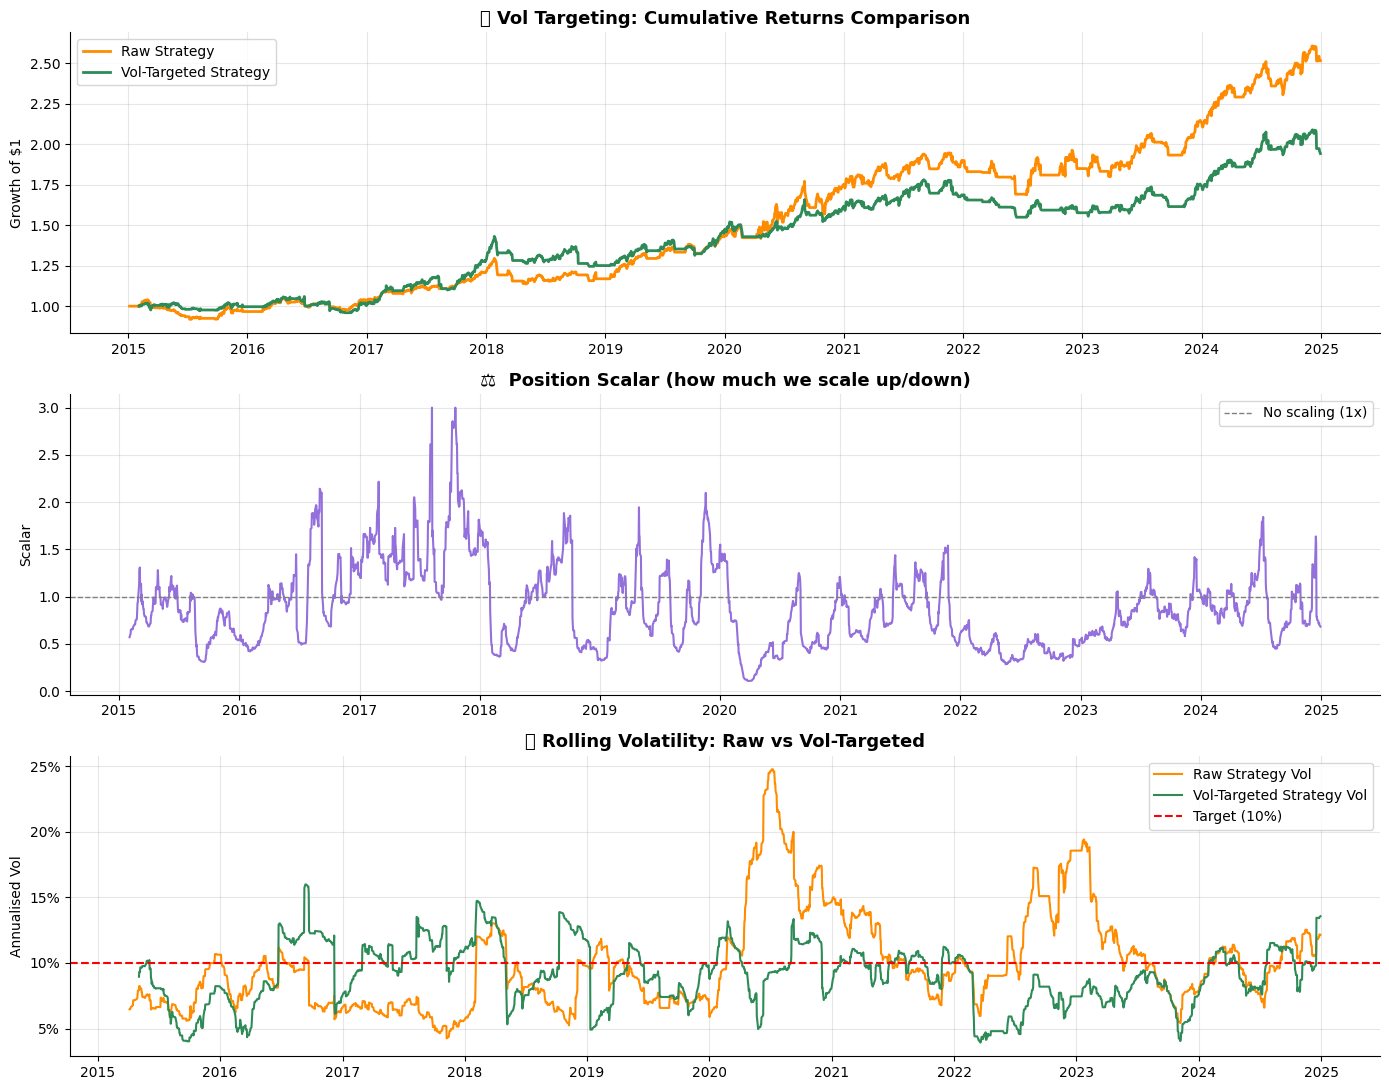

In [ ]:
def volatility_target(returns, signal, target_vol=0.10, lookback=20, cap_scalar=3.0):
    """
    Apply volatility targeting to a strategy.

    Parameters:
        returns    : raw daily returns of underlying
        signal     : position signal (0 or 1)
        target_vol : annualised target volatility (default 10%)
        lookback   : days to estimate realised vol (default 20)
        cap_scalar : max leverage allowed (default 3x)
    """
    # Realised vol (annualised)
    realised_vol = returns.rolling(lookback).std() * np.sqrt(252)
    realised_vol = realised_vol.replace(0, np.nan).ffill()

    # Scalar: how much to scale position
    scalar = (target_vol / realised_vol).clip(upper=cap_scalar)

    # Vol-targeted strategy returns
    vt_returns = signal.shift(1) * scalar.shift(1) * returns
    return vt_returns, scalar


TARGET_VOL = 0.10  # 10% annualised target vol

vt_returns, scalar = volatility_target(
    df['spy_returns'], df['signal'], target_vol=TARGET_VOL
)
vt_returns.name = 'Vol-Targeted Returns'
df['vt_returns'] = vt_returns

sr_vt  = sharpe_ratio(vt_returns.dropna())
mdd_vt = max_drawdown(vt_returns.dropna())[0]
vol_vt = annualised_volatility(vt_returns.dropna())

print(f'  Vol-Targeted Sharpe:   {sr_vt:.2f}   (vs raw strategy: {sr_strategy:.2f})')
print(f'  Vol-Targeted Max DD:   {mdd_vt:.1%}  (vs raw strategy: {mdd_strategy:.1%})')
print(f'  Realised Vol:          {vol_vt:.1%}  (target was {TARGET_VOL:.0%})')

# ── Plotting ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 11))

# Cumulative returns comparison
cum_raw = (1 + df['strategy_returns'].dropna()).cumprod()
cum_vt  = (1 + vt_returns.dropna()).cumprod()
axes[0].plot(cum_raw, label='Raw Strategy',         color='darkorange', lw=2)
axes[0].plot(cum_vt,  label='Vol-Targeted Strategy', color='seagreen',   lw=2)
axes[0].set_title('🎯 Vol Targeting: Cumulative Returns Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Growth of $1')
axes[0].legend()

# Position scalar over time
axes[1].plot(scalar, color='mediumpurple', lw=1.5)
axes[1].axhline(1.0, color='gray', linestyle='--', lw=1, label='No scaling (1x)')
axes[1].set_title('⚖️  Position Scalar (how much we scale up/down)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Scalar')
axes[1].legend()

# Rolling volatility comparison
rv_raw = df['strategy_returns'].rolling(63).std() * np.sqrt(252)
rv_vt  = vt_returns.rolling(63).std() * np.sqrt(252)
axes[2].plot(rv_raw, label='Raw Strategy Vol',          color='darkorange', lw=1.5)
axes[2].plot(rv_vt,  label='Vol-Targeted Strategy Vol',  color='seagreen',   lw=1.5)
axes[2].axhline(TARGET_VOL, color='red', linestyle='--', lw=1.5, label=f'Target ({TARGET_VOL:.0%})')
axes[2].set_title('📊 Rolling Volatility: Raw vs Vol-Targeted', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Annualised Vol')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[2].legend()

plt.tight_layout()
plt.show()

---
## 🔍 Module 4 — Conditional Performance Analysis

This is the heart of statistical intuition — **when does the strategy work, and when does it fail?**

We will slice performance by:
1. **VIX Regime** — low / medium / high volatility environments
2. **Market Trend** — bull market vs bear market
3. **Calendar** — month of year and day of week
4. **Rolling Sharpe** — how Sharpe evolves over time

### 4.1 — Performance by VIX Regime


🌡️  PERFORMANCE BY VIX REGIME

                     Sharpe (Strategy)  Sharpe (Vol-Targeted)  Ann. Return (Strategy)  Ann. Vol (Strategy)  Days in Regime
vix_regime                                                                                                                
Low VIX\n(<15)                    4.23                   3.88                    0.31                 0.07          1012.0
Medium VIX\n(15-25)               0.29                  -0.56                    0.03                 0.11          1147.0
High VIX\n(>25)                  -1.80                  -2.86                   -0.28                 0.16           355.0


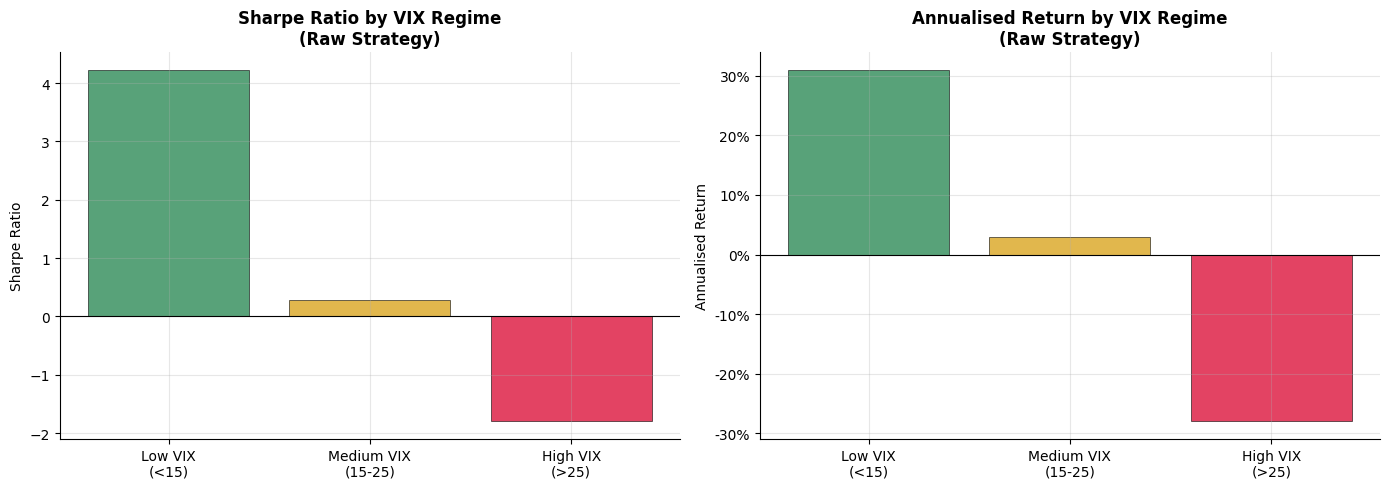


📌 KEY INSIGHT: Does the strategy work better when markets are calm or turbulent?


In [ ]:
# Define VIX regimes
df['vix_regime'] = pd.cut(
    df['vix'],
    bins=[0, 15, 25, 100],
    labels=['Low VIX\n(<15)', 'Medium VIX\n(15-25)', 'High VIX\n(>25)']
)

# Sharpe by regime
regime_stats = df.groupby('vix_regime', observed=True).apply(
    lambda g: pd.Series({
        'Sharpe (Strategy)':      sharpe_ratio(g['strategy_returns']),
        'Sharpe (Vol-Targeted)':  sharpe_ratio(g['vt_returns'].dropna()),
        'Ann. Return (Strategy)': g['strategy_returns'].mean() * 252,
        'Ann. Vol (Strategy)':    annualised_volatility(g['strategy_returns']),
        'Days in Regime':         len(g)
    })
).round(2)

print('\n🌡️  PERFORMANCE BY VIX REGIME\n')
print(regime_stats.to_string())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

regimes = regime_stats.index.tolist()
colors  = ['seagreen', 'goldenrod', 'crimson']

axes[0].bar(regimes, regime_stats['Sharpe (Strategy)'],     color=colors, alpha=0.8, edgecolor='black', lw=0.5)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_title('Sharpe Ratio by VIX Regime\n(Raw Strategy)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Sharpe Ratio')

axes[1].bar(regimes, regime_stats['Ann. Return (Strategy)'], color=colors, alpha=0.8, edgecolor='black', lw=0.5)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('Annualised Return by VIX Regime\n(Raw Strategy)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Annualised Return')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.tight_layout()
plt.show()

print('\n📌 KEY INSIGHT: Does the strategy work better when markets are calm or turbulent?')

### 4.2 — Performance in Bull vs Bear Markets


🐂🐻  PERFORMANCE IN BULL vs BEAR MARKETS

               Sharpe (Strategy)  Sharpe (SPY)  Ann. Return  Max Drawdown  Hit Rate    Days
market_regime                                                                              
Bear Market               -0.250        -0.837       -0.029        -0.142     0.189   607.0
Bull Market                1.354         1.958        0.138        -0.122     0.437  1907.0


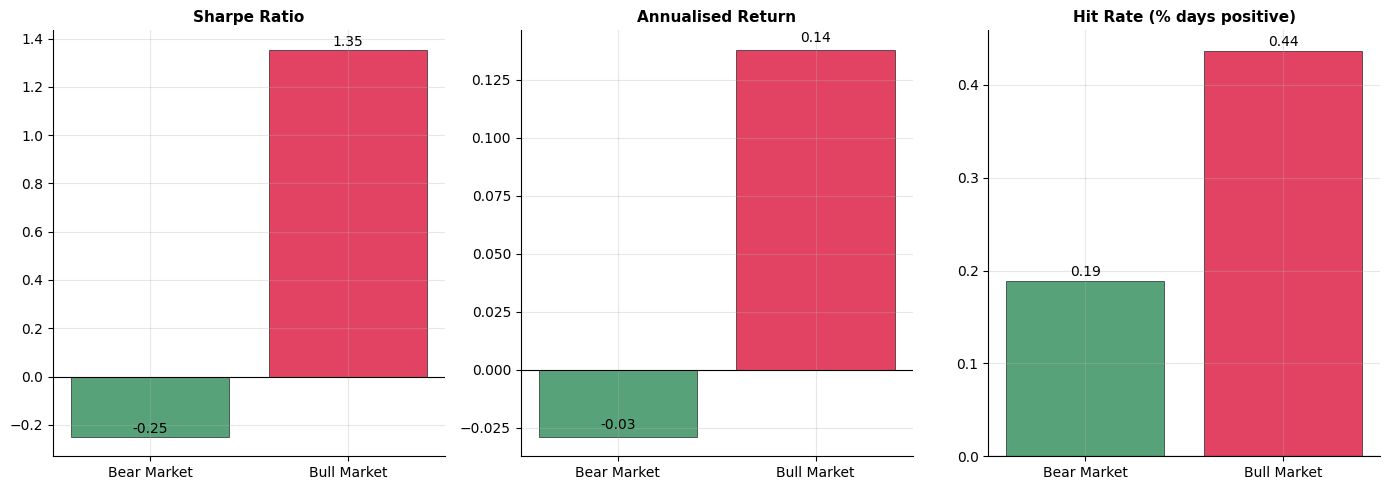

In [ ]:
# Define market regime: 200-day moving average filter
# Bull = SPY above 200-day MA, Bear = SPY below
ma200 = spy.rolling(200).mean()
df['market_regime'] = np.where(spy.reindex(df.index) > ma200.reindex(df.index), 'Bull Market', 'Bear Market')

bull_bear_stats = df.groupby('market_regime').apply(
    lambda g: pd.Series({
        'Sharpe (Strategy)':   sharpe_ratio(g['strategy_returns']),
        'Sharpe (SPY)':        sharpe_ratio(g['spy_returns']),
        'Ann. Return':         g['strategy_returns'].mean() * 252,
        'Max Drawdown':        max_drawdown(g['strategy_returns'])[0],
        'Hit Rate':            (g['strategy_returns'] > 0).mean(),
        'Days':                len(g)
    })
).round(3)

print('\n🐂🐻  PERFORMANCE IN BULL vs BEAR MARKETS\n')
print(bull_bear_stats.to_string())

# Plot
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
regimes = bull_bear_stats.index
colors  = ['seagreen', 'crimson']

metrics = ['Sharpe (Strategy)', 'Ann. Return', 'Hit Rate']
titles  = ['Sharpe Ratio', 'Annualised Return', 'Hit Rate (% days positive)']
formats = ['{:.2f}', '{:.1%}', '{:.1%}']

for ax, metric, title in zip(axes, metrics, titles):
    vals = bull_bear_stats[metric]
    bars = ax.bar(regimes, vals, color=colors, alpha=0.8, edgecolor='black', lw=0.5)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### 4.3 — Calendar Effects (Month of Year & Day of Week)

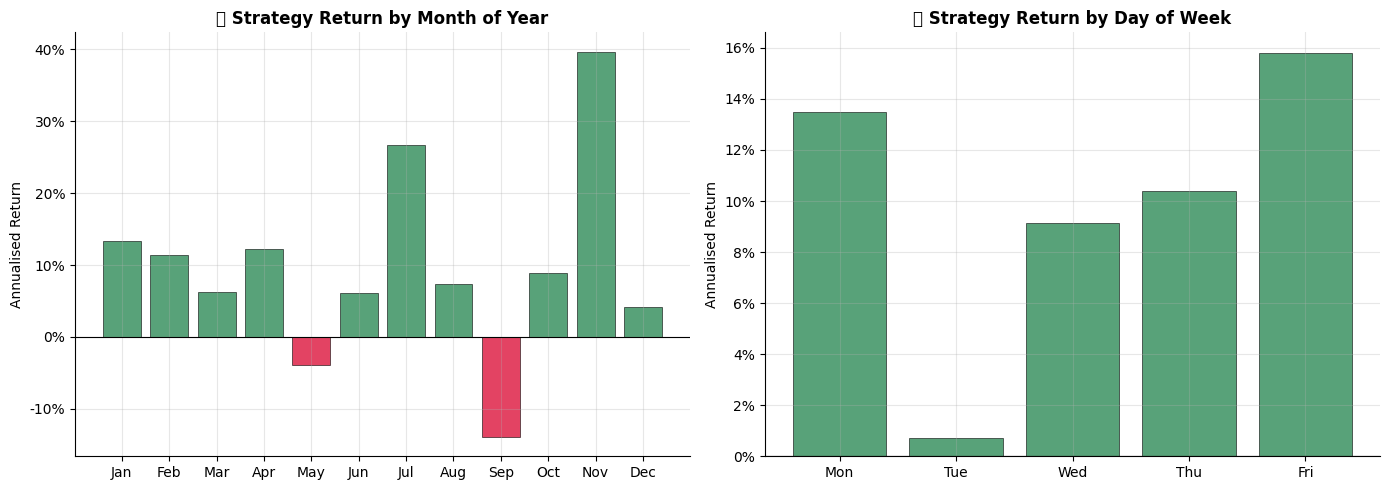

📌 KEY INSIGHT: Are there seasonal patterns in when the strategy works?


In [ ]:
df['month']    = df.index.month
df['month_name'] = df.index.strftime('%b')
df['weekday']  = df.index.dayofweek
df['weekday_name'] = df.index.strftime('%a')

# Monthly Sharpe
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_ret = df.groupby('month_name')['strategy_returns'].mean() * 252
monthly_ret = monthly_ret.reindex(month_order)

# Day of week Sharpe
day_order = ['Mon','Tue','Wed','Thu','Fri']
dow_ret   = df.groupby('weekday_name')['strategy_returns'].mean() * 252
dow_ret   = dow_ret.reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_m = ['seagreen' if v >= 0 else 'crimson' for v in monthly_ret]
axes[0].bar(monthly_ret.index, monthly_ret, color=colors_m, alpha=0.8, edgecolor='black', lw=0.5)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_title('📅 Strategy Return by Month of Year', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Annualised Return')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

colors_d = ['seagreen' if v >= 0 else 'crimson' for v in dow_ret]
axes[1].bar(dow_ret.index, dow_ret, color=colors_d, alpha=0.8, edgecolor='black', lw=0.5)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('📅 Strategy Return by Day of Week', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Annualised Return')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.tight_layout()
plt.show()

print('📌 KEY INSIGHT: Are there seasonal patterns in when the strategy works?')

### 4.4 — Rolling Sharpe Ratio (Strategy Health Over Time)

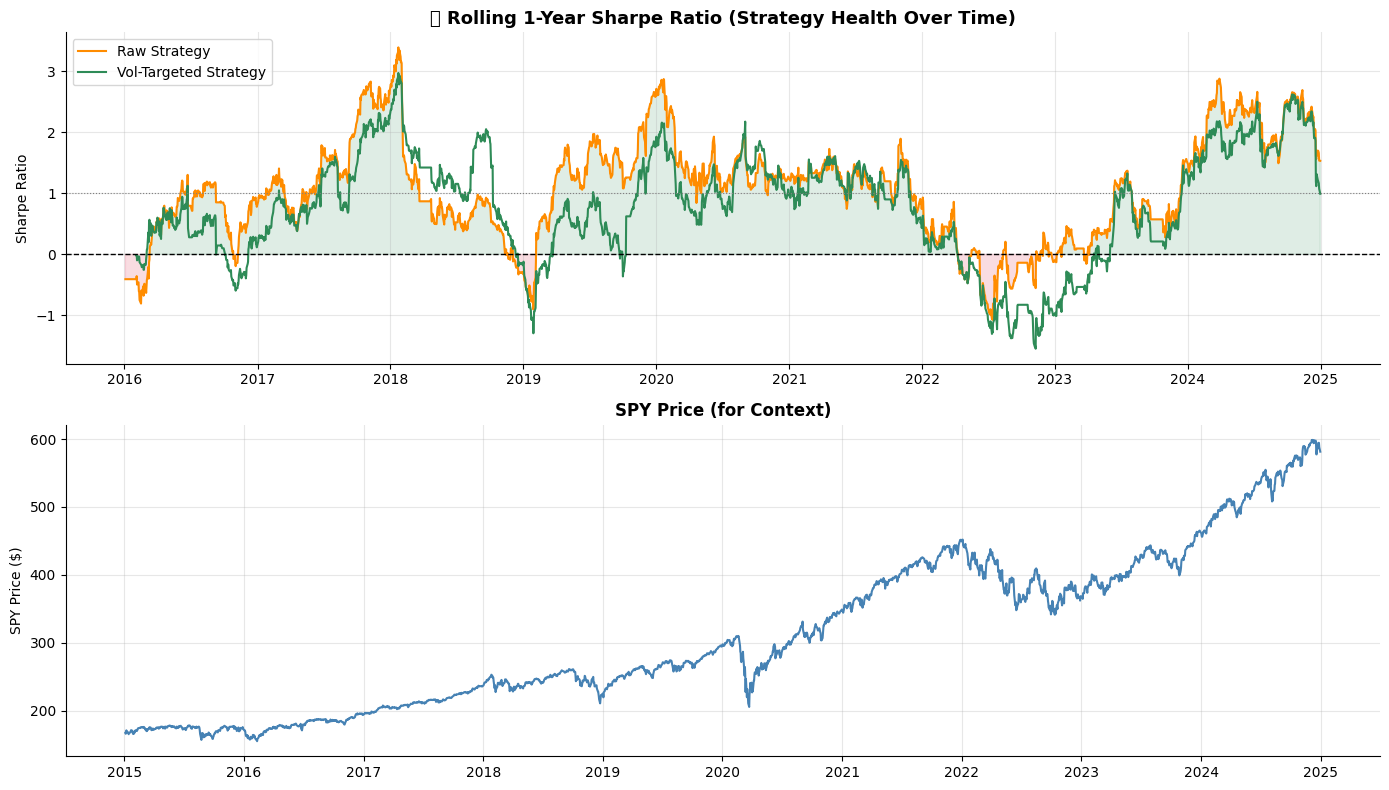

📌 KEY INSIGHT: When rolling Sharpe turns negative, the strategy is in a losing regime.
   Overlay this with market events to understand WHY.


In [ ]:
# Rolling 252-day Sharpe (1-year window)
roll_sharpe = df['strategy_returns'].rolling(252).apply(
    lambda x: sharpe_ratio(pd.Series(x)), raw=False
)

roll_sharpe_vt = df['vt_returns'].rolling(252).apply(
    lambda x: sharpe_ratio(pd.Series(x)), raw=False
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Rolling Sharpe
axes[0].plot(roll_sharpe,    label='Raw Strategy',          color='darkorange', lw=1.5)
axes[0].plot(roll_sharpe_vt, label='Vol-Targeted Strategy', color='seagreen',   lw=1.5)
axes[0].axhline(0, color='black', lw=1, linestyle='--')
axes[0].axhline(1, color='gray',  lw=0.8, linestyle=':')
axes[0].fill_between(roll_sharpe.index, roll_sharpe, 0,
                     where=(roll_sharpe > 0), alpha=0.15, color='seagreen')
axes[0].fill_between(roll_sharpe.index, roll_sharpe, 0,
                     where=(roll_sharpe < 0), alpha=0.15, color='crimson')
axes[0].set_title('📈 Rolling 1-Year Sharpe Ratio (Strategy Health Over Time)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Sharpe Ratio')
axes[0].legend()

# SPY price for context
spy_idx = spy.reindex(df.index)
axes[1].plot(spy_idx, color='steelblue', lw=1.5)
axes[1].set_title('SPY Price (for Context)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('SPY Price ($)')

plt.tight_layout()
plt.show()

print('📌 KEY INSIGHT: When rolling Sharpe turns negative, the strategy is in a losing regime.')
print('   Overlay this with market events to understand WHY.')

---
## 📐 Module 5 — Statistical Intuition: Is Your Edge Real?

Good quant trading is about **statistics**, not just charts.  
Here we test: *is this strategy's performance statistically significant, or is it just luck?*

### 5.1 — T-Test: Is the Mean Return Significantly Positive?

In [ ]:
def t_test_returns(returns, label='Strategy'):
    """
    One-sample t-test: is the mean return significantly different from zero?
    H0: mean return = 0 (no edge)
    H1: mean return > 0 (positive edge)
    """
    clean = returns.dropna()
    t_stat, p_value = stats.ttest_1samp(clean, popmean=0)

    print(f'\n🔬 T-TEST: {label}')
    print(f'  Mean Daily Return : {clean.mean():.4%}')
    print(f'  T-Statistic       : {t_stat:.3f}')
    print(f'  P-Value (2-sided) : {p_value:.4f}')
    print(f'  P-Value (1-sided) : {p_value/2:.4f}')

    if p_value / 2 < 0.01:
        print('  ✅ RESULT: Statistically significant at 1% level — strong evidence of edge')
    elif p_value / 2 < 0.05:
        print('  ✅ RESULT: Statistically significant at 5% level — reasonable evidence of edge')
    elif p_value / 2 < 0.10:
        print('  ⚠️  RESULT: Marginally significant at 10% — weak evidence')
    else:
        print('  ❌ RESULT: NOT statistically significant — could be luck!')

    return t_stat, p_value


t_test_returns(df['strategy_returns'], 'Momentum Strategy')
t_test_returns(df['vt_returns'],       'Vol-Targeted Strategy')


🔬 T-TEST: Momentum Strategy
  Mean Daily Return : 0.0389%
  T-Statistic       : 2.941
  P-Value (2-sided) : 0.0033
  P-Value (1-sided) : 0.0017
  ✅ RESULT: Statistically significant at 1% level — strong evidence of edge

🔬 T-TEST: Vol-Targeted Strategy
  Mean Daily Return : 0.0284%
  T-Statistic       : 2.388
  P-Value (2-sided) : 0.0170
  P-Value (1-sided) : 0.0085
  ✅ RESULT: Statistically significant at 1% level — strong evidence of edge


(np.float64(2.387804317829607), np.float64(0.017023421087903716))

### 5.2 — Return Distribution Analysis

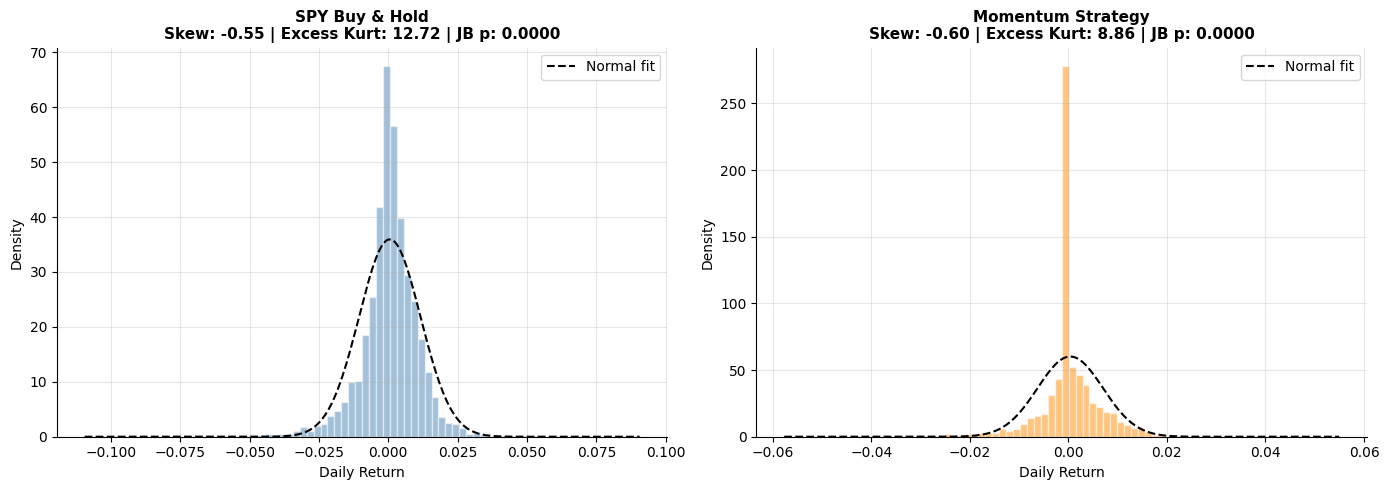

📌 KEY CONCEPTS:
  Skewness > 0  → more positive tail (good)
  Skewness < 0  → more negative tail (bad, fat left tail)
  Excess Kurtosis > 0 → fat tails (more extreme events than normal)
  JB p < 0.05  → returns are NOT normally distributed (common in finance!)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (returns, label, color) in zip(axes, [
    (df['spy_returns'],      'SPY Buy & Hold',   'steelblue'),
    (df['strategy_returns'], 'Momentum Strategy', 'darkorange')
]):
    clean = returns.dropna()

    # Histogram + KDE
    ax.hist(clean, bins=80, density=True, alpha=0.5, color=color, edgecolor='white', lw=0.3)

    # Fit normal distribution for comparison
    mu, sigma = clean.mean(), clean.std()
    x = np.linspace(clean.min(), clean.max(), 300)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'k--', lw=1.5, label='Normal fit')

    # Stats
    skew     = stats.skew(clean)
    kurt     = stats.kurtosis(clean)
    _, jb_p  = stats.jarque_bera(clean)

    ax.set_title(f'{label}\nSkew: {skew:.2f} | Excess Kurt: {kurt:.2f} | JB p: {jb_p:.4f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Daily Return')
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()

print('📌 KEY CONCEPTS:')
print('  Skewness > 0  → more positive tail (good)')
print('  Skewness < 0  → more negative tail (bad, fat left tail)')
print('  Excess Kurtosis > 0 → fat tails (more extreme events than normal)')
print('  JB p < 0.05  → returns are NOT normally distributed (common in finance!)')

### 5.3 — Bootstrap Confidence Interval for Sharpe Ratio

Instead of just reporting one Sharpe number, we use **bootstrapping** to build a confidence interval — showing the range of Sharpe ratios we might expect if we re-ran history many times.


🔄 BOOTSTRAP SHARPE RATIO (2,000 samples, 95% CI)
  Point Estimate : 0.93
  95% CI         : [0.31, 1.57]

  ✅ The entire confidence interval is above 0 — robust positive Sharpe


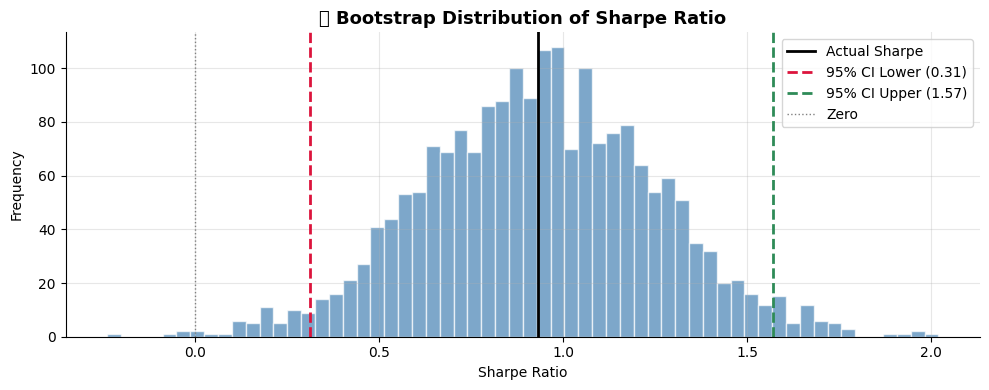

In [ ]:
def bootstrap_sharpe(returns, n_boot=2000, ci=0.95):
    """
    Bootstrap confidence interval for the Sharpe Ratio.
    """
    clean       = returns.dropna().values
    boot_sharpes = []

    for _ in range(n_boot):
        sample = np.random.choice(clean, size=len(clean), replace=True)
        sr     = (sample.mean() / sample.std()) * np.sqrt(252)
        boot_sharpes.append(sr)

    boot_sharpes = np.array(boot_sharpes)
    lower = np.percentile(boot_sharpes, (1 - ci) / 2 * 100)
    upper = np.percentile(boot_sharpes, (1 + ci) / 2 * 100)
    return boot_sharpes, lower, upper


np.random.seed(42)
boot_sr, lo, hi = bootstrap_sharpe(df['strategy_returns'])

print(f'\n🔄 BOOTSTRAP SHARPE RATIO (2,000 samples, 95% CI)')
print(f'  Point Estimate : {sharpe_ratio(df["strategy_returns"]):.2f}')
print(f'  95% CI         : [{lo:.2f}, {hi:.2f}]')
print()
if lo > 0:
    print('  ✅ The entire confidence interval is above 0 — robust positive Sharpe')
else:
    print('  ⚠️  Lower CI is below 0 — Sharpe is uncertain, could be driven by luck')

plt.figure(figsize=(10, 4))
plt.hist(boot_sr, bins=60, color='steelblue', alpha=0.7, edgecolor='white', lw=0.3)
plt.axvline(sharpe_ratio(df['strategy_returns']), color='black',   lw=2,   label='Actual Sharpe')
plt.axvline(lo, color='crimson', lw=2, linestyle='--', label=f'95% CI Lower ({lo:.2f})')
plt.axvline(hi, color='seagreen', lw=2, linestyle='--', label=f'95% CI Upper ({hi:.2f})')
plt.axvline(0,  color='gray',    lw=1, linestyle=':', label='Zero')
plt.title('🔄 Bootstrap Distribution of Sharpe Ratio', fontsize=13, fontweight='bold')
plt.xlabel('Sharpe Ratio')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

### 5.4 — Drawdown Clustering Analysis

Do losses tend to arrive in clusters (bad regimes), or are they randomly spread out?


📉 DRAWDOWN PERIODS (depth > -3%)
  Number of drawdowns: 18
  Average depth:       -6.8%
  Average duration:    134 days
  Worst drawdown:      -13.3%
  Longest drawdown:    427 days

     Start        End     Depth  Duration
2021-11-30 2022-11-30 -0.133363       365
2018-02-02 2019-04-05 -0.121650       427
2015-03-10 2016-04-13 -0.115980       400
2020-09-03 2021-01-07 -0.114153       126
2022-12-06 2023-06-13 -0.082802       189
2024-07-24 2024-11-06 -0.081785       105
2020-06-11 2020-08-04 -0.069895        54
2016-05-04 2017-01-25 -0.069218       266
2023-09-05 2023-12-11 -0.064817        97
2021-05-12 2021-07-26 -0.056892        75


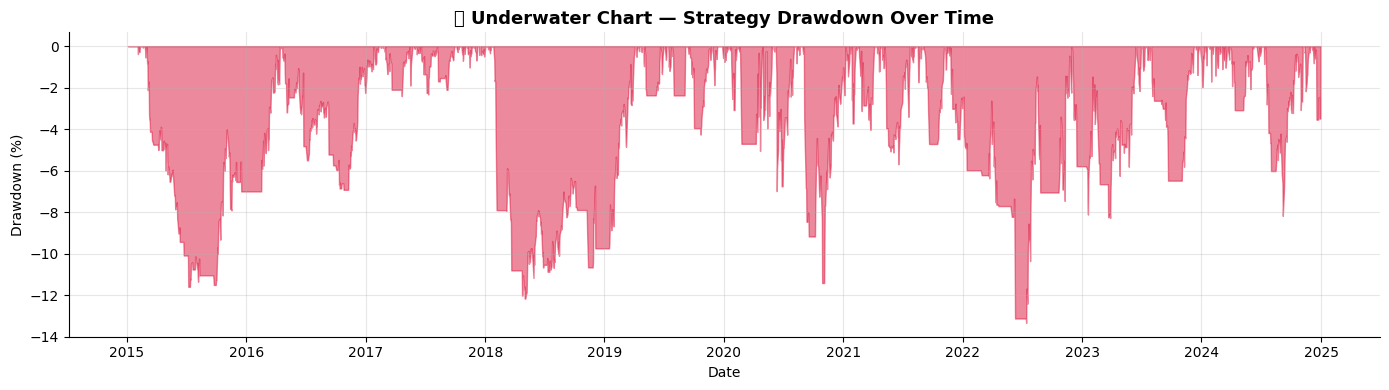

In [ ]:
def drawdown_periods(returns, threshold=-0.05):
    """
    Find all drawdown periods deeper than the threshold.
    Returns a list of dicts with start, end, depth, duration.
    """
    cum  = (1 + returns).cumprod()
    peak = cum.cummax()
    dd   = (cum - peak) / peak

    in_dd     = False
    dd_start  = None
    periods   = []

    for date, val in dd.items():
        if not in_dd and val < threshold:
            in_dd    = True
            dd_start = date
        elif in_dd and val >= 0:
            periods.append({
                'Start':    dd_start,
                'End':      date,
                'Depth':    dd[dd_start:date].min(),
                'Duration': (date - dd_start).days
            })
            in_dd = False

    return pd.DataFrame(periods)


dd_periods = drawdown_periods(df['strategy_returns'], threshold=-0.03)

print(f'\n📉 DRAWDOWN PERIODS (depth > -3%)')
if len(dd_periods) > 0:
    print(f'  Number of drawdowns: {len(dd_periods)}')
    print(f'  Average depth:       {dd_periods["Depth"].mean():.1%}')
    print(f'  Average duration:    {dd_periods["Duration"].mean():.0f} days')
    print(f'  Worst drawdown:      {dd_periods["Depth"].min():.1%}')
    print(f'  Longest drawdown:    {dd_periods["Duration"].max()} days')
    print()
    print(dd_periods.sort_values('Depth').head(10).to_string(index=False))
else:
    print('  No significant drawdown periods found at this threshold.')

# Underwater plot
_, dd_series = max_drawdown(df['strategy_returns'])
plt.figure(figsize=(14, 4))
plt.fill_between(dd_series.index, dd_series * 100, 0, color='crimson', alpha=0.5)
plt.title('🌊 Underwater Chart — Strategy Drawdown Over Time', fontsize=13, fontweight='bold')
plt.ylabel('Drawdown (%)')
plt.xlabel('Date')
plt.tight_layout()
plt.show()

---
## 🏁 Module 6 — Final Dashboard: Everything in One View

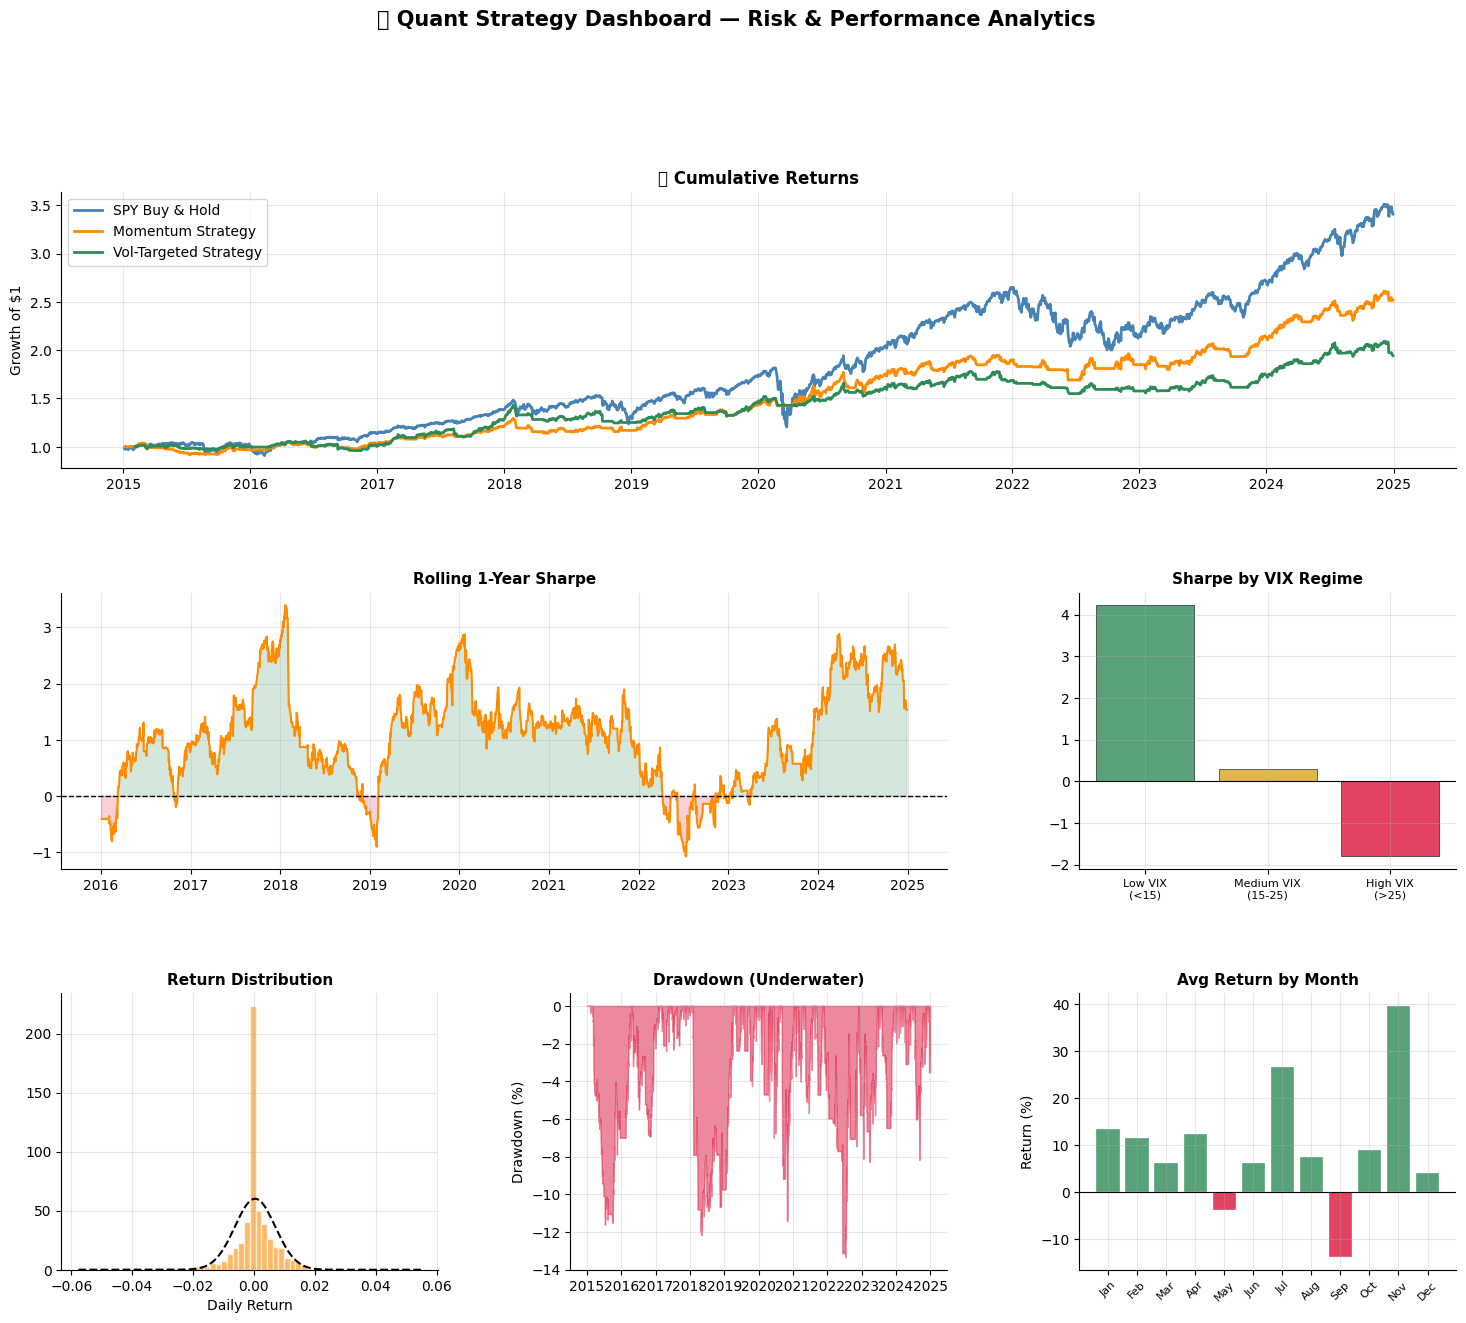

In [ ]:
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1. Cumulative returns
ax1 = fig.add_subplot(gs[0, :])
cum_spy      = (1 + df['spy_returns']).cumprod()
cum_strategy = (1 + df['strategy_returns']).cumprod()
cum_vt       = (1 + df['vt_returns'].dropna()).cumprod()
ax1.plot(cum_spy,      label='SPY Buy & Hold',       color='steelblue',  lw=2)
ax1.plot(cum_strategy, label='Momentum Strategy',     color='darkorange', lw=2)
ax1.plot(cum_vt,       label='Vol-Targeted Strategy', color='seagreen',   lw=2)
ax1.set_title('📈 Cumulative Returns', fontsize=12, fontweight='bold')
ax1.set_ylabel('Growth of $1')
ax1.legend()

# 2. Rolling Sharpe
ax2 = fig.add_subplot(gs[1, :2])
ax2.plot(roll_sharpe, color='darkorange', lw=1.5)
ax2.axhline(0, color='black', lw=1, linestyle='--')
ax2.fill_between(roll_sharpe.index, roll_sharpe, 0,
                 where=(roll_sharpe > 0), alpha=0.2, color='seagreen')
ax2.fill_between(roll_sharpe.index, roll_sharpe, 0,
                 where=(roll_sharpe < 0), alpha=0.2, color='crimson')
ax2.set_title('Rolling 1-Year Sharpe', fontsize=11, fontweight='bold')

# 3. VIX regime Sharpe bars
ax3 = fig.add_subplot(gs[1, 2])
vals   = regime_stats['Sharpe (Strategy)']
colors = ['seagreen', 'goldenrod', 'crimson']
ax3.bar(range(len(vals)), vals, color=colors, alpha=0.8, edgecolor='black', lw=0.5)
ax3.set_xticks(range(len(vals)))
ax3.set_xticklabels([r.replace('\n', '\n') for r in vals.index.tolist()], fontsize=8)
ax3.axhline(0, color='black', lw=0.8)
ax3.set_title('Sharpe by VIX Regime', fontsize=11, fontweight='bold')

# 4. Return distribution
ax4 = fig.add_subplot(gs[2, 0])
clean = df['strategy_returns'].dropna()
ax4.hist(clean, bins=60, color='darkorange', alpha=0.6, density=True, edgecolor='white', lw=0.2)
mu, sigma = clean.mean(), clean.std()
x = np.linspace(clean.min(), clean.max(), 200)
ax4.plot(x, stats.norm.pdf(x, mu, sigma), 'k--', lw=1.5)
ax4.set_title('Return Distribution', fontsize=11, fontweight='bold')
ax4.set_xlabel('Daily Return')

# 5. Underwater plot
ax5 = fig.add_subplot(gs[2, 1])
_, dd_s = max_drawdown(df['strategy_returns'])
ax5.fill_between(dd_s.index, dd_s * 100, 0, color='crimson', alpha=0.5)
ax5.set_title('Drawdown (Underwater)', fontsize=11, fontweight='bold')
ax5.set_ylabel('Drawdown (%)')

# 6. Monthly returns heatmap-style
ax6 = fig.add_subplot(gs[2, 2])
monthly_ret_plot = monthly_ret.dropna()
colors_m = ['seagreen' if v >= 0 else 'crimson' for v in monthly_ret_plot]
ax6.bar(monthly_ret_plot.index, monthly_ret_plot * 100, color=colors_m, alpha=0.8, edgecolor='white', lw=0.3)
ax6.axhline(0, color='black', lw=0.8)
ax6.set_title('Avg Return by Month', fontsize=11, fontweight='bold')
ax6.set_ylabel('Return (%)')
ax6.tick_params(axis='x', rotation=45, labelsize=8)

fig.suptitle('🏁 Quant Strategy Dashboard — Risk & Performance Analytics',
             fontsize=15, fontweight='bold', y=1.01)
plt.show()

---
## 📚 Summary — What You Learned

| Concept | What It Tells You |
|---|---|
| **Sharpe Ratio** | Return per unit of risk (higher = better) |
| **Max Drawdown** | Worst peak-to-trough loss |
| **Volatility** | Total risk (standard deviation of returns, annualised) |
| **Turnover** | How often the strategy trades (cost driver) |
| **Vol Targeting** | Scale position size to maintain constant risk |
| **VIX Regime** | Does strategy work in calm vs turbulent markets? |
| **Bull/Bear Market** | Does strategy outperform in up-trends or down-trends? |
| **Rolling Sharpe** | Is the strategy's edge stable or decaying? |
| **T-Test** | Is performance statistically significant or just luck? |
| **Bootstrap CI** | What range of Sharpe ratios could we realistically expect? |
| **Return Distribution** | Are returns fat-tailed? Skewed? Normal? |

---

## 🚀 Next Steps

1. **Try different assets** — change `'SPY'` to `'QQQ'`, `'GLD'`, `'BTC-USD'`
2. **Change the signal** — try different lookback windows (10, 50, 100 days)
3. **Add transaction costs** — subtract a small cost per trade from strategy returns
4. **Combine signals** — momentum + mean reversion + carry
5. **Walk-forward testing** — train on one period, test on the next (out-of-sample validation)
6. **Add more assets** — build a multi-asset portfolio and analyse correlation

